## **Лабораторная работа №1 по Компьютерному зрению <br> «Нейронная сеть с нуля для MNIST»**

#### **Цель:**
Продемонстрировать знание архитектуры простых нейронных сетей.

#### **Задачи:**
• Написать от двух моделей нейронных сетей без использования специализированных
библиотек. (использовать разные слои, ф-ции активации, ф-ции потерь). <br>
• Испытать работу написанный моделей на датасете картинок рукописных цифр MNIST. <br>
• Сравнить работу написанных моделей, выбрать «лучшую», сделать выводы.

#### **Выполнили:**
Гайфиев Иван <br>
Прокопец Артём <br>
Цирулёв Дмитрий

### Импорт библиотек
Для написания нейросети воспользуемся фреймворком numpy, а для загрузки датасета - tensorflow

In [1]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.6 MB/s eta 0:00:00


In [3]:
import numpy as np, matplotlib.pyplot as plt
import tensorflow as tf # only for loading dataset
import os

### Загрузка и предобработка данных
Сначала загрузим изображения MNIST, предобработаем и добавим 1000 изображений кастомного датасета, созданного нами самими.

In [4]:
# Loading from Tensorflow.Keras
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
print(x_train.shape, # 60 thousand of handwritten digits in size 28 x 28 pixels (3D-array), values from 0 to 255
      y_train.shape) # 60 thousand of correct digits (1D-array), target variables

(60000, 28, 28) (60000,)


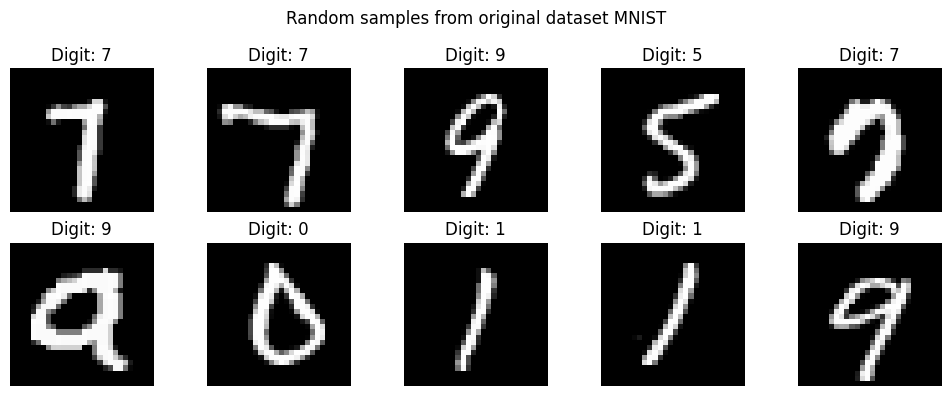

In [17]:
# vizualization of the dataset MNIST
def plot_images(images, labels=None, rows=2, cols=5, title=None, figsize=(10,4)):
    im_d0 = images.shape[0]
    im_d1 = images.shape[1]
    if im_d1 == 784:
      images = np.reshape(images, (im_d0, 28, 28))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()
    for i in range(rows*cols):
        axes[i].imshow(images[i], cmap='gray')
        axes[i].axis('off')
        if labels is not None:
          axes[i].set_title(f"Digit: {labels[i]}")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# choosing random samples of digits in original dataset
random_indices = np.random.randint(1, 60000, size=10)
random_images = x_train[random_indices]
random_lables = y_train[random_indices]

plot_images(random_images, random_lables, title="Random samples from original dataset MNIST")

In [7]:
# PREPROCESSING (for more convenient process of teaching the model)

# Normalization
x_train = x_train / 255
x_test = x_test / 255

# Flatteing (array to a vector)
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

# One-hot encoding
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y] # binarization of target variable

y_train_onehot = one_hot(y_train)
y_test_onehot = one_hot(y_test)

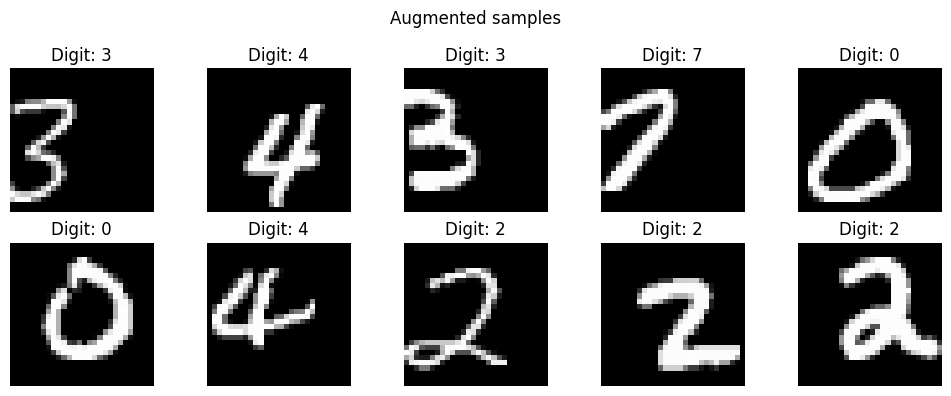

In [19]:
# AUGMENTATION (for extending dataset and increasing accuracy)
def shift_image(image, dx, dy):
    img = image.reshape(28, 28)
    shifted = np.zeros_like(img)
    if dx > 0:
        shifted[:, dx:] = img[:, :-dx]
    elif dx < 0:
        shifted[:, :dx] = img[:, -dx:]
    else:
        shifted = img.copy()

    if dy > 0:
        shifted[dy:, :] = shifted[:-dy, :]
    elif dy < 0:
        shifted[:dy, :] = shifted[-dy:, :]

    return shifted.reshape(-1)

def augment_image(image):
    dx = np.random.randint(-3, 3)
    dy = np.random.randint(-2, 3)
    return shift_image(image, dx, dy)

def get_augmented_batch(X, y, size=5000):
    indices = np.random.choice(len(X), size, replace=False)
    x_aug = np.array([augment_image(X[i]) for i in indices])
    y_aug = y[indices]
    return x_aug, y_aug

x_aug, y_aug = get_augmented_batch(x_train_flat, y_train, size=10000)
y_aug_onehot = one_hot(y_aug)

plot_images(x_aug, y_aug, title="Augmented samples")

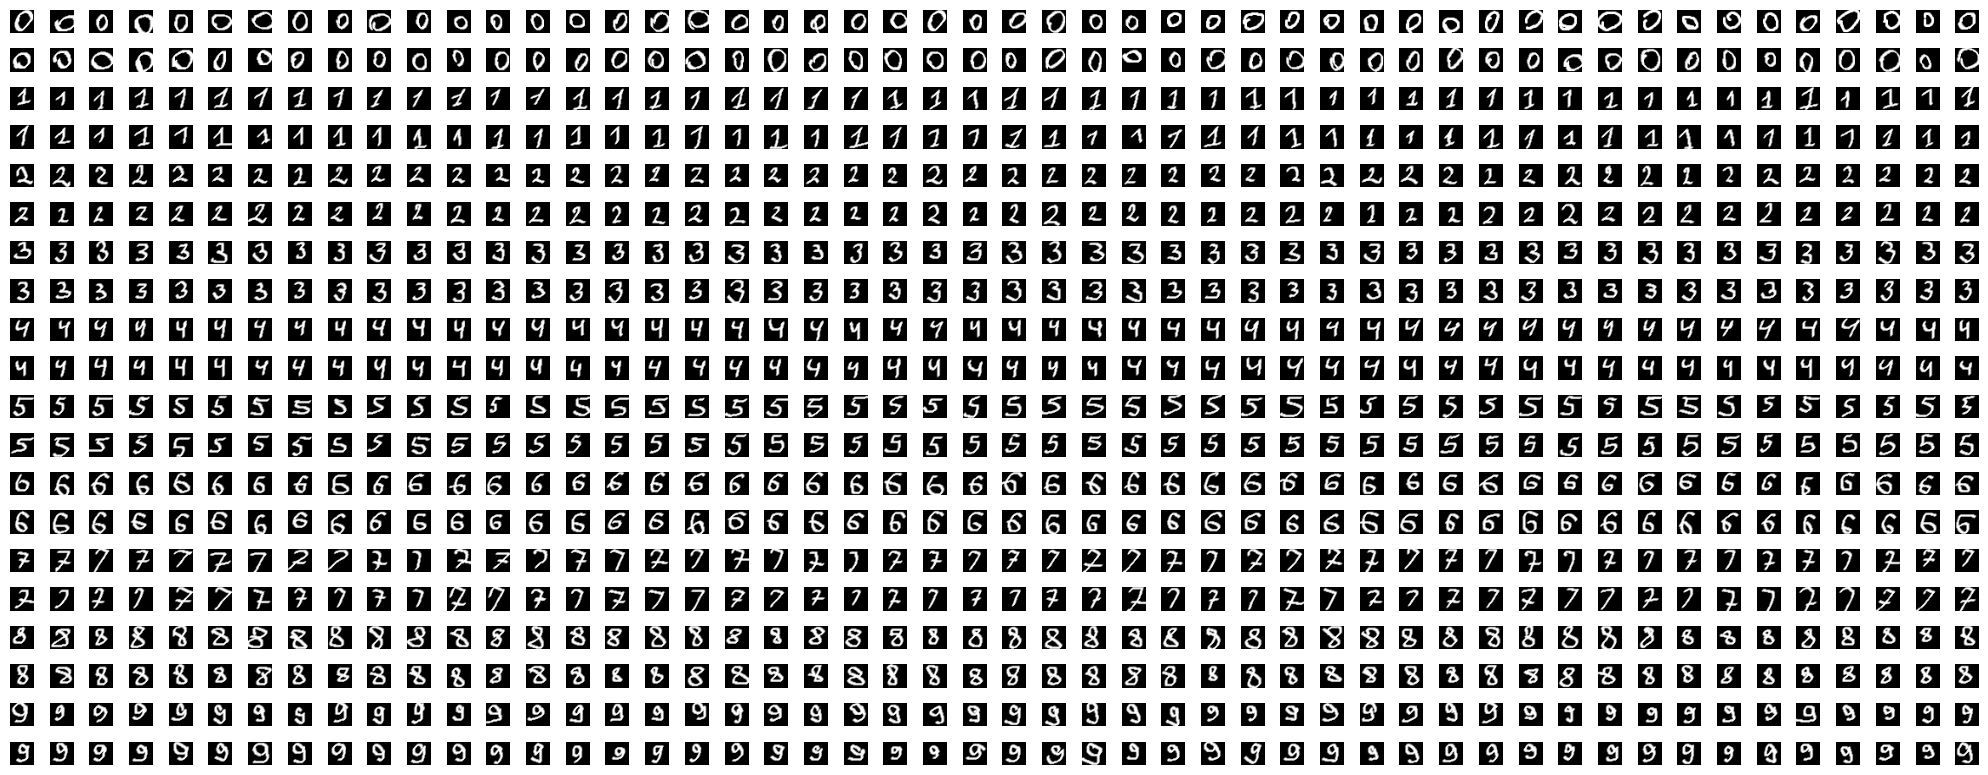

In [ ]:
# OUR KILLER FEATURE - custom dataset with 1000 images of digits that we wrote by ourselves
# program with algorithm of creating the dataset also attached (otherwise may be requested)
x_custom_flat = np.load("1000 custom digits x.npy")
y_custom = np.load("1000 custom digits y.npy")

# visualization of the custom dataset
plot_images(x_custom_flat, None, 20, 50, figsize=(20,8))

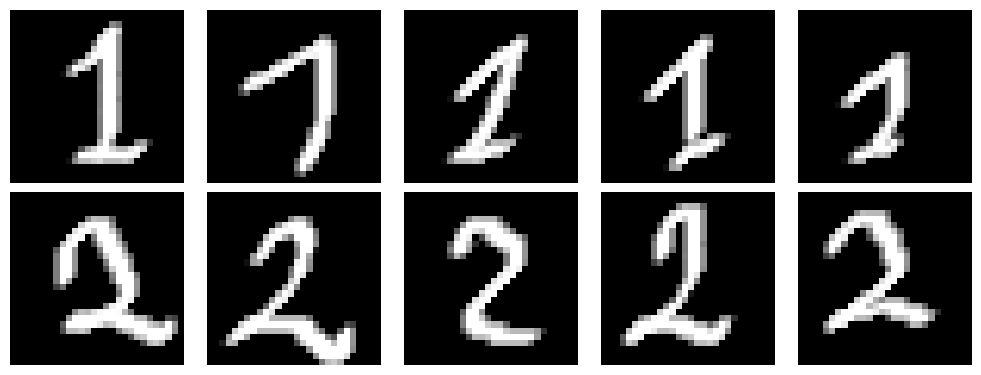

In [21]:
plot_images(x_custom_flat[195:205], None, 2, 5, figsize=(10,4))

In [ ]:
# Join custom dataset with original one
x_train_flat = np.concatenate((x_train_flat, x_custom_flat), axis=0) # 60000 + 1000
y_train = np.concatenate((y_train, y_custom), axis=0) # 60000 + 1000
y_train_onehot = one_hot(y_train) # 61000

# Join augmented dataset with all previous
x_train_extended = np.concatenate((x_train_flat, x_aug)) # 71000
y_train_extended = np.concatenate((y_train_onehot, y_aug_onehot)) # 71000

In [ ]:
print(f"New size of dataset (MNIST + custom data): {x_train_flat.shape}, {y_train.shape}") # 61000, 61000
print(f"New size of dataset (MNIST + custom data + augmented): {x_train_extended.shape}, {y_train_extended.shape}") # 71000, 71000

New size of dataset (MNIST + custom data): (61000, 784), (61000,)
New size of dataset (MNIST + custom data + augmented): (71000, 784), (71000, 10)


### Определение классов нейронной сети
В этой части мы описываем классы, которые описывают разные слои нейронной сети, добавляя в них методы forward и bachward propagation. Эти классы, как составные части сети, потом позволят нам собрать модель воедино и затем запустить процесс обучения


In [ ]:
class Layer:
    """Base class for all neural network layers."""
    def forward(self, x): pass
    def backward(self, grad_output): pass

class Linear(Layer):
    """Fully connected linear layer.

    Performs transformation: output = x @ W + b, where W is weight matrix
    and b is bias vector. Stores input and gradients for backward pass.
    """
    def __init__(self, in_features, out_features):
        limit = np.sqrt(6 / (in_features + out_features)) # Xavier initialization for constant dispersion between layers
        self.W = np.random.uniform(-limit, limit, (in_features, out_features)) # matrix of weights
        self.b = np.zeros((1, out_features)) # biases vector
        self.grad_W = self.grad_b = self.x = None

    def forward(self, x):
        self.x = x
        return x @ self.W + self.b # linear combination

    def backward(self, grad_output):
        self.grad_W = self.x.T @ grad_output
        self.grad_b = np.sum(grad_output, axis=0, keepdims=True)
        return grad_output @ self.W.T

### Функции активации

In [ ]:
class ReLU(Layer):
    """Rectified Linear Unit activation function.

    Applies f(x) = max(0, x). Stores binary mask of positive inputs
    for efficient gradient computation during backward pass.
    """
    def forward(self, x):
        self.mask = (x > 0)
        return x * self.mask
    def backward(self, grad_output):
        return grad_output * self.mask

class Tanh(Layer):
    """Hyperbolic tangent activation function.

    Applies f(x) = tanh(x), squashing input to range [-1, 1].
    Stores output for efficient gradient computation during backward pass.
    """
    def forward(self, x):
        self.out = np.tanh(x)
        return self.out
    def backward(self, grad_output):
        return grad_output * (1 - self.out**2)

class Heaviside(Layer):
    """Heaviside step activation function.

    Applies binary threshold: returns 1 if x >= 0, else 0.
    Note: Gradient is zero everywhere except at x=0 where it's undefined.
    """
    def forward(self, x):
        return (x >= 0).astype(np.float32)
    def backward(self, grad_output):
        return np.zeros_like(grad_output)

### Функции потерь

In [ ]:
class SoftmaxCrossEntropyLoss(Layer):
    """Combined Softmax activation and Cross-Entropy loss layer.

    Computes softmax probabilities and cross-entropy loss in forward pass,
    and gradient of loss with respect to logits in backward pass.
    """
    def forward(self, logits, y_true):
        self.y_true = y_true
        self.batch_size = logits.shape[0]
        logits_shifted = logits - np.max(logits, axis=1, keepdims=True)
        exp_logits = np.exp(logits_shifted)
        self.softmax = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
        loss = -np.sum(y_true * np.log(self.softmax + 1e-15)) / self.batch_size
        return loss
    def backward(self):
        return (self.softmax - self.y_true) / self.batch_size

class MSELoss(Layer):
    """Mean Squared Error loss layer.

    Computes MSE loss in forward pass and its gradient
    with respect to predictions in backward pass.
    """
    def forward(self, y_pred, y_true):
        self.y_pred = y_pred
        self.y_true = y_true
        self.batch_size = y_pred.shape[0]
        return np.mean((y_pred - y_true)**2)
    def backward(self):
        return 2 * (self.y_pred - self.y_true) / self.batch_size

### Sequential и оптимизатор SGD

In [ ]:
class Sequential:
    """Container for stacking layers in sequence.

    Passes data through layers in forward order and gradients in reverse.
    """
    def __init__(self, layers): self.layers = layers
    def forward(self, x):
        for layer in self.layers: x = layer.forward(x)
        return x
    def backward(self, grad):
        for layer in reversed(self.layers): grad = layer.backward(grad)
    def parameters(self):
        return [(l.W, l.b) for l in self.layers if hasattr(l, 'W')]
    def gradients(self):
        return [(l.grad_W, l.grad_b) for l in self.layers if hasattr(l, 'grad_W')]

class SGD:
    """Stochastic Gradient Descent optimizer.

    Updates parameters using gradients with learning rate.
    """
    def __init__(self, parameters, lr=0.01):
        self.parameters = parameters
        self.lr = lr
    def step(self, grads):
        for (W, b), (gW, gb) in zip(self.parameters, grads):
            W -= self.lr * gW
            b -= self.lr * gb

### Функция обучения модели
Создает модель и оптимизатор, выполняет обучение по эпохам с перемешиванием данных и мини-батчами.
    
Возвращает: потери на обучении, точность на тесте, обученную модель.

In [ ]:
def train_model(layers, loss_fn, lr=0.1, epochs=15, batch_size=64):
    model = Sequential(layers)
    optimizer = SGD(model.parameters(), lr=lr)
    num_batches = x_train_extended.shape[0] // batch_size
    train_losses = []
    test_accs = []

    for epoch in range(epochs):
        idx = np.random.permutation(x_train_extended.shape[0])
        x_shuf = x_train_extended[idx]
        y_shuf = y_train_extended[idx]
        epoch_loss = 0.0

        for b in range(num_batches):
            xb = x_shuf[b*batch_size:(b+1)*batch_size]
            yb = y_shuf[b*batch_size:(b+1)*batch_size]
            out = model.forward(xb)
            loss = loss_fn.forward(out, yb)
            grad = loss_fn.backward()
            model.backward(grad)
            optimizer.step(model.gradients())
            epoch_loss += loss

        avg_loss = epoch_loss / num_batches
        train_losses.append(avg_loss)

        # Test accuracy
        test_out = model.forward(x_test_flat)
        preds = np.argmax(test_out, axis=1)
        acc = np.mean(preds == y_test)
        test_accs.append(acc)

        print(f"Эпоха {epoch+1}: loss={avg_loss:.4f} test_acc={acc:.4f}")

    return train_losses, test_accs, model

В ходе лабораторной работы были реализованы и обучены несколько вариантов нейронных сетей на датасете MNIST. Основная цель заключалась в сравнении различных функций активации (ReLU, Tanh, Heaviside) и функций потерь (CrossEntropy, MSE)

### Модель 1: ReLU + CrossEntropy

Эпоха 1: loss=0.4288 test_acc=0.9561
Эпоха 2: loss=0.1809 test_acc=0.9657
Эпоха 3: loss=0.1249 test_acc=0.9737
Эпоха 4: loss=0.0963 test_acc=0.9748
Эпоха 5: loss=0.0779 test_acc=0.9764
Эпоха 6: loss=0.0650 test_acc=0.9783
Эпоха 7: loss=0.0540 test_acc=0.9794
Эпоха 8: loss=0.0447 test_acc=0.9783
Эпоха 9: loss=0.0385 test_acc=0.9807
Эпоха 10: loss=0.0320 test_acc=0.9797
Эпоха 11: loss=0.0272 test_acc=0.9807
Эпоха 12: loss=0.0230 test_acc=0.9806
Эпоха 13: loss=0.0187 test_acc=0.9807
Эпоха 14: loss=0.0148 test_acc=0.9794
Эпоха 15: loss=0.0137 test_acc=0.9811


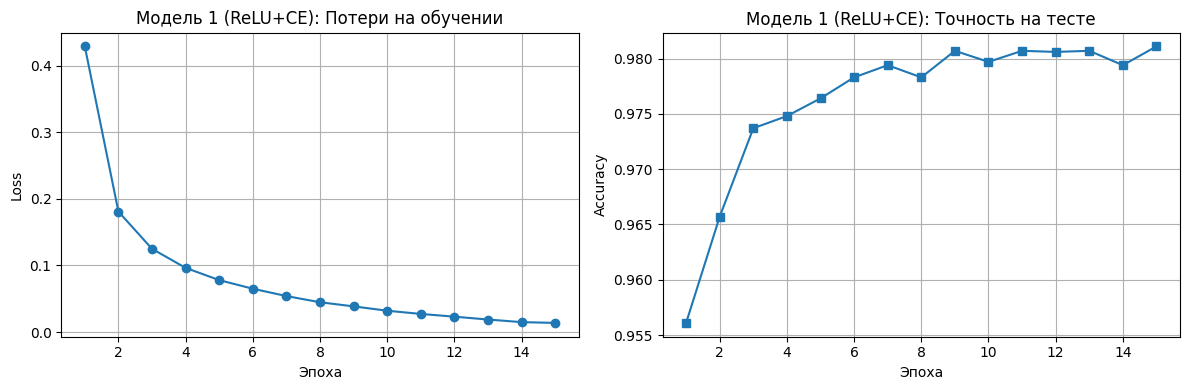

In [ ]:
model1_layers = [
    Linear(784, 128),
    ReLU(),
    Linear(128, 64),
    ReLU(),
    Linear(64, 10)
]
loss_fn1 = SoftmaxCrossEntropyLoss()
train_loss1, test_acc1, model1 = train_model(model1_layers, loss_fn1, lr=0.1, epochs=15)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(1,16), train_loss1, marker='o')
plt.title('Модель 1 (ReLU+CE): Потери на обучении')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(range(1,16), test_acc1, marker='s')
plt.title('Модель 1 (ReLU+CE): Точность на тесте')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

Отличный результат показала модель ReLU + CrossEntropy. Это объясняется удачным сочетанием свойств. ReLU задаётся формулой f(x)=max(0,x), её производная равна 1 для положительных аргументов и 0 для отрицательных. Благодаря этому градиенты не затухают при прохождении через положительную область, а в нашем случае с одним скрытым слоем ускоряет сходимость. Функция потерь CrossEntropy даёт хороший градиент по логитам, который прямо пропорционален ошибке и направляет веса в сторону увеличения вероятности правильного класса.

### Модель 2: Tanh + CrossEntropy

Эпоха 1: loss=0.4691 test_acc=0.9444
Эпоха 2: loss=0.2454 test_acc=0.9618
Эпоха 3: loss=0.1666 test_acc=0.9665
Эпоха 4: loss=0.1265 test_acc=0.9749
Эпоха 5: loss=0.1012 test_acc=0.9761
Эпоха 6: loss=0.0834 test_acc=0.9790
Эпоха 7: loss=0.0695 test_acc=0.9803
Эпоха 8: loss=0.0590 test_acc=0.9798
Эпоха 9: loss=0.0506 test_acc=0.9800
Эпоха 10: loss=0.0434 test_acc=0.9787
Эпоха 11: loss=0.0377 test_acc=0.9819
Эпоха 12: loss=0.0322 test_acc=0.9825
Эпоха 13: loss=0.0280 test_acc=0.9828
Эпоха 14: loss=0.0243 test_acc=0.9831
Эпоха 15: loss=0.0209 test_acc=0.9833


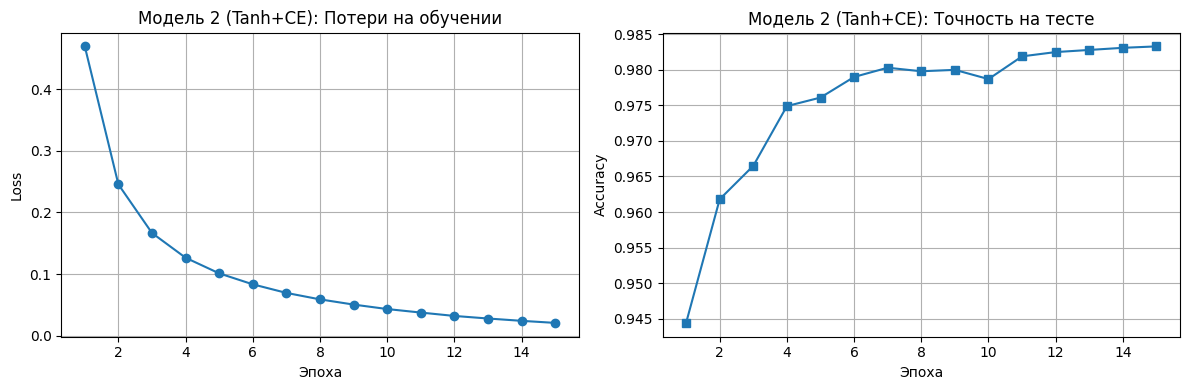

In [ ]:
model2_layers = [
    Linear(784, 256),
    Tanh(),
    Linear(256, 128),
    Tanh(),
    Linear(128, 10)
]
loss_fn2 = SoftmaxCrossEntropyLoss()
train_loss2, test_acc2, model2 = train_model(model2_layers, loss_fn2, lr=0.1, epochs=15)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(1,16), train_loss2, marker='o')
plt.title('Модель 2 (Tanh+CE): Потери на обучении')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(range(1,16), test_acc2, marker='s')
plt.title('Модель 2 (Tanh+CE): Точность на тесте')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

Не хуже показала себя модель Tanh + CrossEntropy. Tanh сжимает выходы в интервал (-1, 1) и центрирован около нуля. При этом его производная 1 - tanh^2(x) стремится к нулю при больших значениях. Поэтому сеть быстро и стабильно улучшает точность.

### Модель 3: Heaviside + CrossEntropy

Эпоха 1: loss=1.6620 test_acc=0.5494
Эпоха 2: loss=1.4895 test_acc=0.5536
Эпоха 3: loss=1.4725 test_acc=0.5426
Эпоха 4: loss=1.4671 test_acc=0.5586
Эпоха 5: loss=1.4651 test_acc=0.5624
Эпоха 6: loss=1.4641 test_acc=0.5557
Эпоха 7: loss=1.4623 test_acc=0.5552
Эпоха 8: loss=1.4618 test_acc=0.5592
Эпоха 9: loss=1.4619 test_acc=0.5554
Эпоха 10: loss=1.4617 test_acc=0.5591
Эпоха 11: loss=1.4616 test_acc=0.5597
Эпоха 12: loss=1.4611 test_acc=0.5575
Эпоха 13: loss=1.4609 test_acc=0.5570
Эпоха 14: loss=1.4611 test_acc=0.5581
Эпоха 15: loss=1.4603 test_acc=0.5592


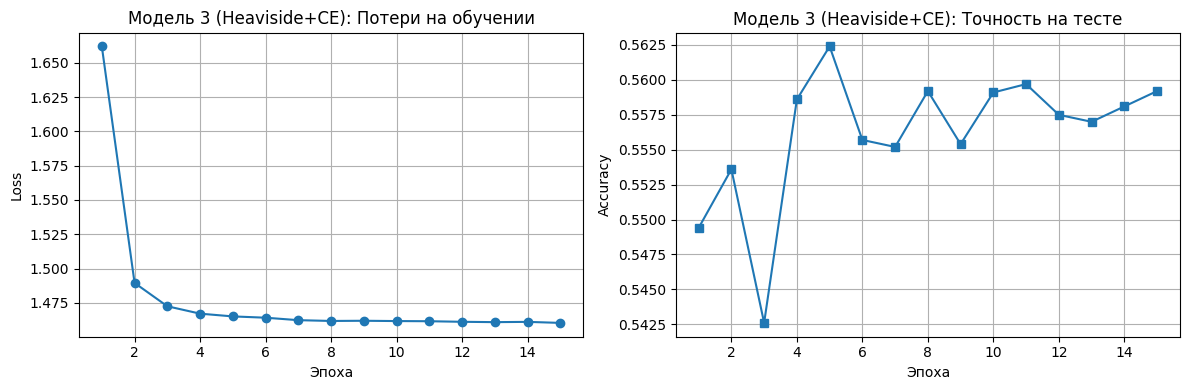

In [ ]:
model3_layers = [
    Linear(784, 128),
    Heaviside(),
    Linear(128, 64),
    Heaviside(),
    Linear(64, 10)
]
loss_fn3 = SoftmaxCrossEntropyLoss()
train_loss3, test_acc3, model3 = train_model(model3_layers, loss_fn3, lr=0.1, epochs=15)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(1,16), train_loss3, marker='o')
plt.title('Модель 3 (Heaviside+CE): Потери на обучении')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(range(1,16), test_acc3, marker='s')
plt.title('Модель 3 (Heaviside+CE): Точность на тесте')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

Низкие результаты получены при использовании функции активации Хевисайда как с CrossEntropy, так и с MSE. Причина кроется в её производной: функция Хевисайда равна 1 при положительном входе и 0 в остальных случаях, но её производная равна нулю всюду, кроме точки разрыва, где она не определена. При обратном распространении через такой слой градиент умножается на ноль, и сигнал ошибки не проходит к предыдущим слоям. Веса практически перестают обновляться, и обучение останавливается.

### Модель 4: ReLU + MSE

Эпоха 1: loss=0.0282 test_acc=0.9488
Эпоха 2: loss=0.0146 test_acc=0.9625
Эпоха 3: loss=0.0115 test_acc=0.9674
Эпоха 4: loss=0.0097 test_acc=0.9686
Эпоха 5: loss=0.0086 test_acc=0.9723
Эпоха 6: loss=0.0078 test_acc=0.9713
Эпоха 7: loss=0.0071 test_acc=0.9725
Эпоха 8: loss=0.0066 test_acc=0.9742
Эпоха 9: loss=0.0062 test_acc=0.9751
Эпоха 10: loss=0.0058 test_acc=0.9739
Эпоха 11: loss=0.0055 test_acc=0.9752
Эпоха 12: loss=0.0052 test_acc=0.9743
Эпоха 13: loss=0.0050 test_acc=0.9765
Эпоха 14: loss=0.0048 test_acc=0.9761
Эпоха 15: loss=0.0046 test_acc=0.9757


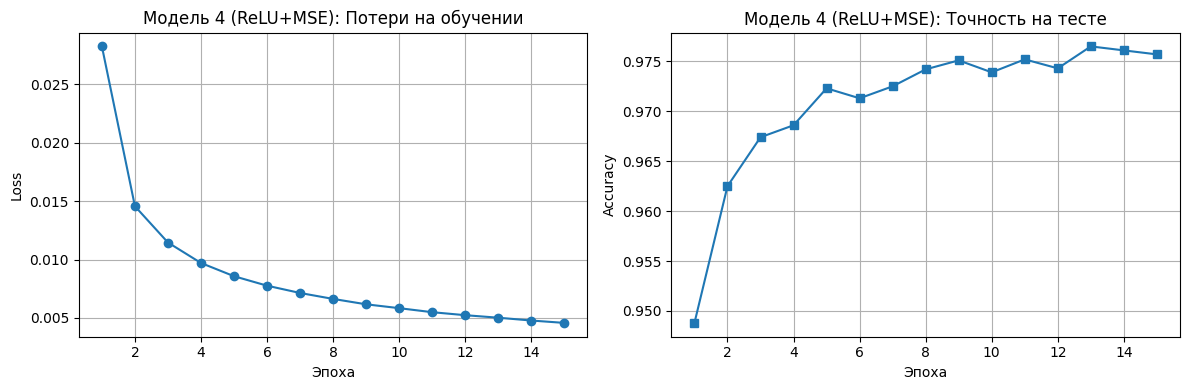

In [ ]:
model4_layers = [
    Linear(784, 128),
    ReLU(),
    Linear(128, 64),
    ReLU(),
    Linear(64, 10)
]
loss_fn4 = MSELoss()
train_loss4, test_acc4, model4 = train_model(model4_layers, loss_fn4, lr=0.1, epochs=15)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(1,16), train_loss4, marker='o')
plt.title('Модель 4 (ReLU+MSE): Потери на обучении')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(range(1,16), test_acc4, marker='s')
plt.title('Модель 4 (ReLU+MSE): Точность на тесте')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

Интересно, что комбинация ReLU+MSE оказалась ближе к ReLU+CrossEntropy, чем Tanh+MSE к Tanh+CrossEntropy. Это можно связать с тем, что ReLU избегает насыщения, и даже с неоптимальной функцией потерь градиенты остаются достаточно большими для обучения. Tanh усиливается из-за того, что MSE может дополнительно уменьшать градиенты при приближении к правильному ответу.

### Модель 5: Tanh + MSE

Эпоха 1: loss=0.0523 test_acc=0.9025
Эпоха 2: loss=0.0345 test_acc=0.9248
Эпоха 3: loss=0.0291 test_acc=0.9337
Эпоха 4: loss=0.0261 test_acc=0.9386
Эпоха 5: loss=0.0240 test_acc=0.9453
Эпоха 6: loss=0.0226 test_acc=0.9491
Эпоха 7: loss=0.0213 test_acc=0.9505
Эпоха 8: loss=0.0204 test_acc=0.9522
Эпоха 9: loss=0.0196 test_acc=0.9537
Эпоха 10: loss=0.0189 test_acc=0.9570
Эпоха 11: loss=0.0183 test_acc=0.9566
Эпоха 12: loss=0.0178 test_acc=0.9596
Эпоха 13: loss=0.0173 test_acc=0.9597
Эпоха 14: loss=0.0169 test_acc=0.9594
Эпоха 15: loss=0.0165 test_acc=0.9587


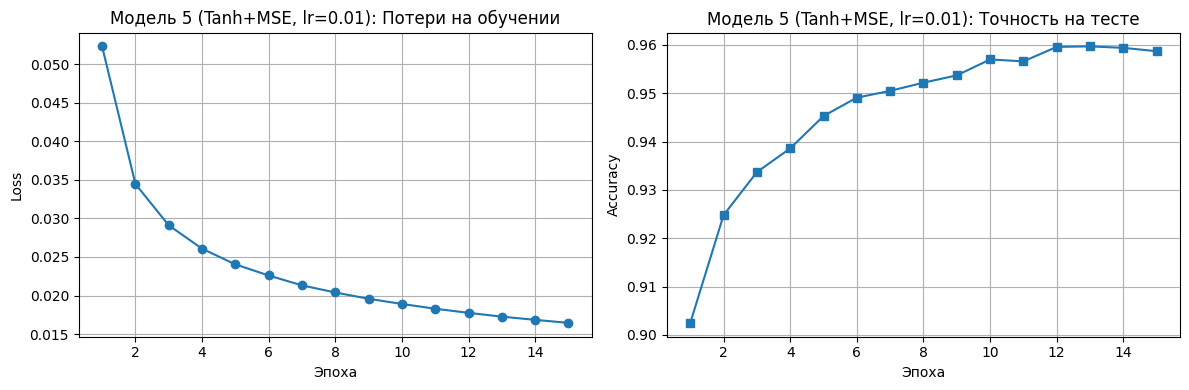

In [ ]:
model5_layers = [
    Linear(784, 256),
    Tanh(),
    Linear(256, 128),
    Tanh(),
    Linear(128, 10)
]
loss_fn5 = MSELoss()
train_loss5, test_acc5, model5 = train_model(model5_layers, loss_fn5, lr=0.01, epochs=15)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(1,16), train_loss5, marker='o')
plt.title('Модель 5 (Tanh+MSE, lr=0.01): Потери на обучении')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(range(1,16), test_acc5, marker='s')
plt.title('Модель 5 (Tanh+MSE, lr=0.01): Точность на тесте')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

Сравнение функций потерь показывает, что CrossEntropy превосходит MSE для задачи классификации. Хотя комбинации с MSE (ReLU+MSE и Tanh+MSE) тоже дают приемлемую точность, они уступают аналогам с CrossEntropy примерно на 1–2%. Математически это объясняется тем, что среднеквадратичная ошибка MSE предназначена для регрессии и не учитывает вероятностную интерпретацию выходов. При использовании softmax на выходе градиент MSE будет другим, так как он не учитывает конкуренцию между классами. MSE может давать очень малые градиенты при малых ошибках, замедляя сходимость на поздних этапах. CrossEntropy же напрямую максимизирует логарифм правдоподобия правильного класса, то есть соответствует цели классификации.

### Модель 6: Heaviside + MSE

Эпоха 1: loss=0.1091 test_acc=0.5015
Эпоха 2: loss=0.0749 test_acc=0.5281
Эпоха 3: loss=0.0737 test_acc=0.5215
Эпоха 4: loss=0.0734 test_acc=0.5288
Эпоха 5: loss=0.0733 test_acc=0.5249
Эпоха 6: loss=0.0732 test_acc=0.5235
Эпоха 7: loss=0.0731 test_acc=0.5136
Эпоха 8: loss=0.0731 test_acc=0.5374
Эпоха 9: loss=0.0731 test_acc=0.5145
Эпоха 10: loss=0.0731 test_acc=0.5274
Эпоха 11: loss=0.0731 test_acc=0.5322
Эпоха 12: loss=0.0731 test_acc=0.5308
Эпоха 13: loss=0.0731 test_acc=0.5261
Эпоха 14: loss=0.0731 test_acc=0.5297
Эпоха 15: loss=0.0731 test_acc=0.5255


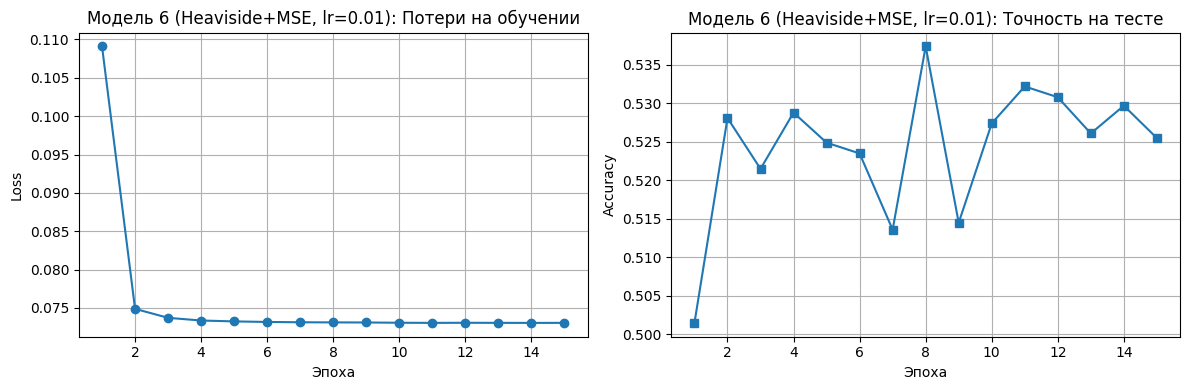

In [ ]:
model6_layers = [
    Linear(784, 128),
    Heaviside(),
    Linear(128, 64),
    Heaviside(),
    Linear(64, 10)
]
loss_fn6 = MSELoss()
train_loss6, test_acc6, model6 = train_model(model6_layers, loss_fn6, lr=0.01, epochs=15)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(1,16), train_loss6, marker='o')
plt.title('Модель 6 (Heaviside+MSE, lr=0.01): Потери на обучении')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(range(1,16), test_acc6, marker='s')
plt.title('Модель 6 (Heaviside+MSE, lr=0.01): Точность на тесте')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

Дифференцируемые функции активации (ReLU, Tanh) позволяют градиентному спуску эффективно обновлять веса, тогда как недифференцируемые (Heaviside) делают обучение практически невозможным. ReLU демонстрирует лучшую сходимость благодаря линейности для положительных значений и отсутствию насыщения, это особенно заметно в комбинации с CrossEntropy. Для многоклассовой классификации функция потерь CrossEntropy предпочтительнее MSE.

### Сравнение всех моделей

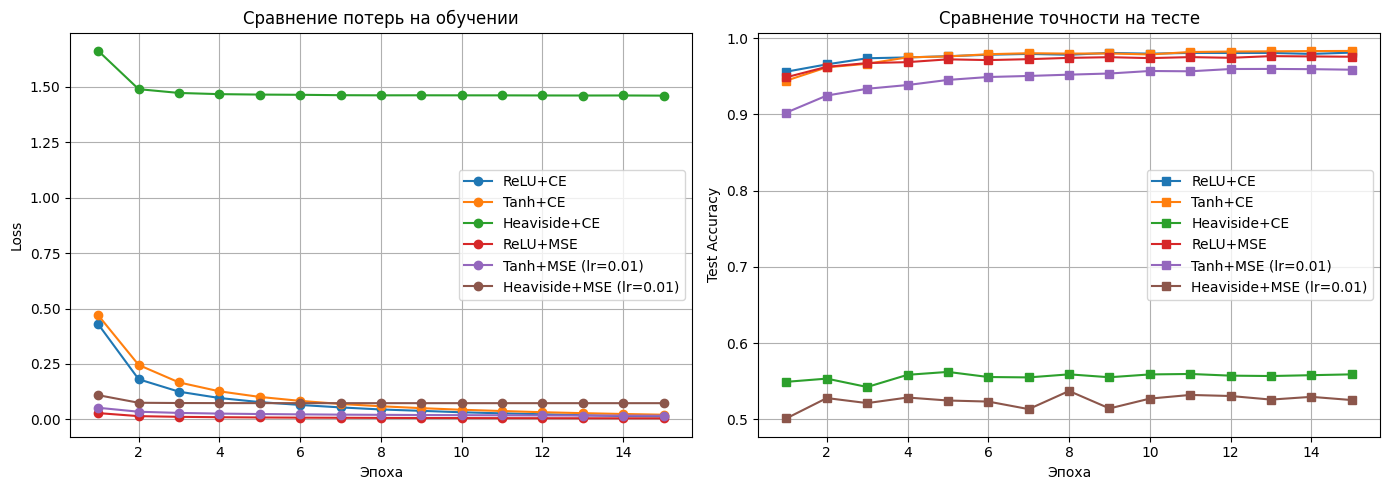

Лучшая модель: Tanh+CE с точностью 0.9833


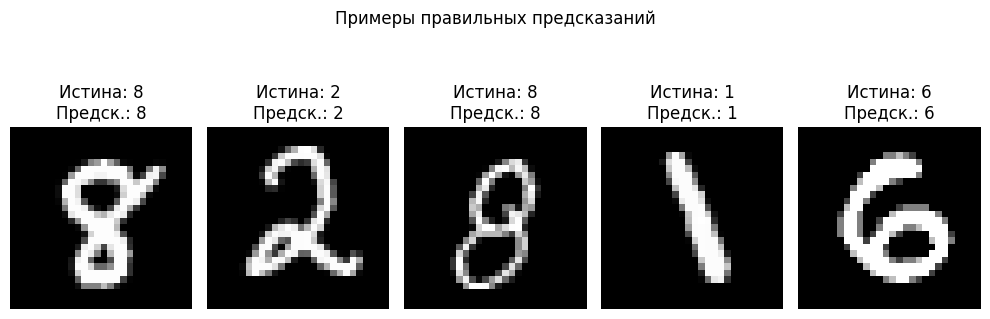

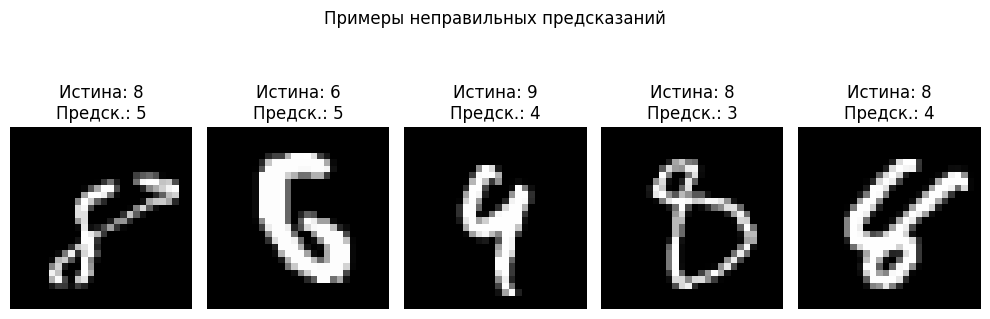

In [ ]:
names = ["ReLU+CE", "Tanh+CE", "Heaviside+CE", "ReLU+MSE", "Tanh+MSE (lr=0.01)", "Heaviside+MSE (lr=0.01)"]
train_losses = [train_loss1, train_loss2, train_loss3, train_loss4, train_loss5, train_loss6]
test_accs = [test_acc1, test_acc2, test_acc3, test_acc4, test_acc5, test_acc6]

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
for i, name in enumerate(names):
    plt.plot(range(1,16), train_losses[i], marker='o', label=name)
plt.xlabel('Эпоха'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.title('Сравнение потерь на обучении')

plt.subplot(1,2,2)
for i, name in enumerate(names):
    plt.plot(range(1,16), test_accs[i], marker='s', label=name)
plt.xlabel('Эпоха'); plt.ylabel('Test Accuracy'); plt.legend(); plt.grid(True)
plt.title('Сравнение точности на тесте')

plt.tight_layout()
plt.show()

final_accs = [acc[-1] for acc in test_accs]
best_idx = np.argmax(final_accs)
best_name = names[best_idx]
best_acc = final_accs[best_idx]
best_model = [model1, model2, model3, model4, model5, model6][best_idx]

print(f"Лучшая модель: {best_name} с точностью {best_acc:.4f}")

best_preds = np.argmax(best_model.forward(x_test_flat), axis=1)

correct = np.where(best_preds == y_test)[0]
incorrect = np.where(best_preds != y_test)[0]

# Correct predictions
plt.figure(figsize=(10,4))
for i, idx in enumerate(np.random.choice(correct, 5, replace=False)):
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Истина: {y_test[idx]}\nПредск.: {best_preds[idx]}")
    plt.axis('off')
plt.suptitle("Примеры правильных предсказаний")
plt.tight_layout(); plt.show()

# Wrong predictions
plt.figure(figsize=(10,4))
for i, idx in enumerate(np.random.choice(incorrect, 5, replace=False)):
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Истина: {y_test[idx]}\nПредск.: {best_preds[idx]}")
    plt.axis('off')
plt.suptitle("Примеры неправильных предсказаний")
plt.tight_layout(); plt.show()

### Сравнение нашей лучшей модели с предобученной из интернета
Лучшей моделью оказалась Tanh + Cross-Entropy с точностью 0.9833 на 15ой эпохе.
В коде ниже мы обучаем найденную в интеренете написанную модель YOLO-26-n, архитектура которой соответсвует модели CNN с 5 слоями свёртки. И сравниваем её показатели с результатом обучения нашей лучшей модели


In [ ]:
from ultralytics import YOLO # YOLO - You Only Look Once

# Load a model
model = YOLO("yolo26n-cls.pt")  # load a pretrained model (recommended for training)

# Train the model
results = model.train(data="mnist", epochs=10, imgsz=28)

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=mnist, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=28, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, po

KeyboardInterrupt: 

В отличие от нашей модели под номером 2 (Tanh + Cross-Entropy), которая состоит всего лишь из 5 небольших слоёв, 3 из которых - линейные полносвязные, найденная структура сети обладает 11-ью слоями, некотрые из которых являются свёрточными. То есть архитектура нашей сети и найденной принципиально отличаются.
Это различие стало заметну сразу в разнице времени обучения: наша простенькая модель обучалась всего 2 минуты на 15 эпохах в то время как YOLO затратила около часа на 9 эпох. <br>


Ключевые отличия моделей:
1) Архитектура: Глубокая CNN с нормализацией по батчам, пулингом и современными активациями (SiLU/Swish) против нашей простой полносвязной моделью перцептрона с Tanh активациями.
2) Работа с изображениями: Свёртки против flattening, который теряет пространственные отношения между пикселями.
3) Размерность: YOLO обладает более чем 1,500,000 параметрами, а наша - около 230,000

Преимущество YOLO - свёртки, современные техники обучения и большое количество параметров. <br>
Преимущество нашей Tanh + CE - легковестность, простота и интерпретируемость <br>

Итоговый вердикт по результатам обучения обеих моделей: <br>
Наша модель обучилась быстро, но её точность оказалась ниже, чем точность YOLO за то же количество эпох.


